In [36]:
# jax ecosystem
import jax

# jax.config.update("jax_enable_x64", False)
jax.config.update("jax_enable_x64", True)
# jax.config.update("jax_platform_name", "gpu")
jax.config.update("jax_debug_nans", False)

device = jax.local_devices()[0]
print(device.device_kind)

import jax.numpy as np
import jax.tree as jtu
import jax.random as jr

# amigo
import dorito
import amigo
import dLux
import zodiax

# matplotlib ecosystem
import matplotlib.pyplot as plt
import matplotlib as mpl
import ehtplot
import scienceplots

# other
import pandas as pd
import os
import sys

# matplotlib parameters
plt.style.use(["science", "bright", "no-latex"])
plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.size"] = 8
plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.direction"] = "out"

def get_cmap(cmap_name: str):
    cmap = mpl.colormaps[cmap_name]
    cmap.set_bad("k", 0.5)
    return cmap

inferno = get_cmap("inferno")
seismic = get_cmap("seismic")
coolwarm = get_cmap("coolwarm")

cpu


# Loading in data

In [37]:
# Setting data path
from socket import gethostname

if (
    gethostname() == "maxs-mbp-14.shared.sydney.edu.au"
    or gethostname() == "Maxs-MacBook-Pro-14.local"
):
    data_dir = "/Volumes/research-data/PRJ-PAT/max/data/JWST/"
    cache_dir = "/Volumes/research-data/PRJ-PAT/max/data/amigo_cache"
    amigo_files_path = "/Volumes/research-data/PRJ-PAT/max/data/amigo_files/v_0.0.11"
    output_path = "/Users/mc/nt_outputs/local_retrain"

elif gethostname().startswith("max-"):
    data_dir = "/home/dgxuser/max/data/JWST/"
    cache_dir = "/home/dgxuser/max/data/amigo_cache"
    amigo_files_path = "/home/dgxuser/max/data/amigo_files/v_0.0.11"
    output_path = "/home/dgxuser/max/outputs/retrain"

else:
    data_dir = "/fred/oz440/max/data/JWST/"
    cache_dir = "/fred/oz440/max/data/amigo_cache"
    amigo_files_path = "/fred/oz440/max/data/amigo_files/v_0.0.11"
    output_path = "/fred/oz440/max/outputs/retrain"

In [19]:
def sort_files(files, n):
    files.sort(key=lambda x: (x[0].header["PROGRAM"], x[0].header["FILTER"], x[0].header["PATT_NUM"]), reverse=True)
    filts = ["F480M", "F430M", "F380M"]
    these_files = {}
    for filt in filts:
        x = []
        for file in files:
            if file[0].header["FILTER"] == filt:
                if one_filt_flag and filt != "F480M":
                    continue
                x.append(file)
        these_files[filt] = x[0:n]
    files = [f for sub_f in these_files.values() for f in sub_f]
    return files

In [45]:
# LOADING IN DATA
from astropy.io import fits
from amigo.files import get_files

print()
print("CAL8330 - Benjamin Pope")
program_path = os.path.join(data_dir, "8330/calslope/")
files = get_files(program_path, "nis_calslope")
calbin_files += files
calbin_files = [file for file in calbin_files if file[0].header["NGROUPS"] > 3]
calbin_files = [add_badpix(file) for file in calbin_files]
files = sort_files(calbin_files, n_files_per_filt)
summarise_files(files)


CAL8330 - Benjamin Pope
   program    target filter dither     g/i        date              PI    CAL
0     8330  V-EZ-Aqr  F480M   6/10  18/220  11-11-2025  Pope, Benjamin  False
1     8330  V-EZ-Aqr  F480M   6/10  18/220  11-11-2025  Pope, Benjamin  False
2     8330  V-EZ-Aqr  F480M   7/10  18/220  11-11-2025  Pope, Benjamin  False
3     8330  V-EZ-Aqr  F480M   7/10  18/220  11-11-2025  Pope, Benjamin  False
4     8330  V-EZ-Aqr  F480M   7/10  18/220  11-11-2025  Pope, Benjamin  False
5     8330  V-EZ-Aqr  F480M   7/10  18/220  11-11-2025  Pope, Benjamin  False
6     8330  V-EZ-Aqr  F480M   8/10  18/220  11-11-2025  Pope, Benjamin  False
7     8330  V-EZ-Aqr  F480M   8/10  18/220  11-11-2025  Pope, Benjamin  False
8     8330  V-EZ-Aqr  F480M   8/10  18/220  11-11-2025  Pope, Benjamin  False
9     8330  V-EZ-Aqr  F480M   8/10  18/220  11-11-2025  Pope, Benjamin  False
10    8330  V-EZ-Aqr  F480M   9/10  18/220  11-11-2025  Pope, Benjamin  False
11    8330  V-EZ-Aqr  F480M   9/10  18/

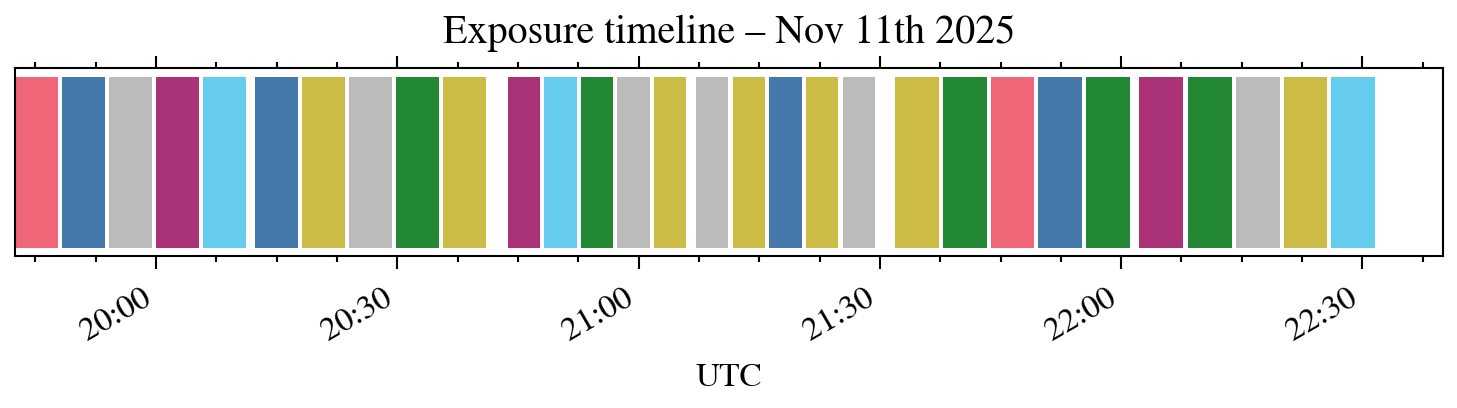

In [52]:
from pathlib import Path
from astropy.io import fits
from astropy.time import Time
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

records = []
for f in files:
    hdr = f[0].header
    t_beg = Time(hdr["DATE-BEG"], format="isot", scale="utc")
    t_end = Time(hdr["DATE-END"], format="isot", scale="utc")
    records.append({
        "file": hdr["FILENAME"],
        "start": t_beg.datetime,
        "end": t_end.datetime,
        "filter": hdr.get("FILTER", ""),   # grab whatever else is useful
        "instrume": hdr.get("INSTRUME", ""),
        "duration": hdr["DURATION"]
    })

# --- plot as a timeline (horizontal bars, one per exposure) ---
fig, ax = plt.subplots(figsize=(5, 1.5))

for i, r in enumerate(records):
    ax.barh(
        y=0,
        width=r["end"] - r["start"],
        left=r["start"],
        height=0.6,
    )
    # ax.text(r["start"], 0, f"{r['duration']}", va="center", fontsize=8)

ax.set_yticks([])
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
fig.autofmt_xdate()
ax.set_xlabel("UTC")
ax.set_title("Exposure timeline – Nov 11th 2025")
plt.tight_layout()
plt.show()

binary_astrometry.py

Predict the relative astrometry (separation rho, position angle theta) of a
visual binary star at a given date, from its published Keplerian orbital
elements.

Method: standard Thiele-Innes projection of a Keplerian orbit onto the sky
plane. See any visual-binary orbit reference (e.g. the USNO Sixth Catalog of
Orbits of Visual Binary Stars, ORB6) for the underlying formulas.

Usage:
    python binary_astrometry.py                      # predicts for now (UTC)
    python binary_astrometry.py 2025-11-11T21:00:00   # predicts for a given date/time

Edit the ELEMENTS dict below to point at a different binary.

In [53]:
# ---------------------------------------------------------------------------
# Orbital elements. Defaults here are for EZ Aquarii A-B
# (WDS 22385-1519 = BLA 10AB, Gl 866 / GJ 866).
# Replace these with elements for any other visual binary you care about.
# ---------------------------------------------------------------------------
ELEMENTS = {
    "P":  2.2506,     # orbital period, years
    "T":  1987.236,   # epoch of periastron passage, decimal year
    "e":  0.437,      # eccentricity
    "a":  0.346,      # angular semi-major axis, arcsec
    "i":  112.4,      # inclination, degrees
    "Om": 162.1,      # position angle of the ascending node (Omega), degrees
    "om": -17.7,      # argument of periastron (omega), degrees
}



In [60]:

def _thiele_innes_constants(a, i_deg, Om_deg, om_deg):
    """Compute the four Thiele-Innes constants A, B, F, G from the
    geometric orbital elements (a, i, Omega, omega). These are
    time-independent and only need to be computed once per orbit."""
    i = np.radians(i_deg)
    Om = np.radians(Om_deg)
    om = np.radians(om_deg)

    A = a * (np.cos(Om) * np.cos(om) - np.sin(Om) * np.sin(om) * np.cos(i))
    B = a * (np.sin(Om) * np.cos(om) + np.cos(Om) * np.sin(om) * np.cos(i))
    F = a * (-np.cos(Om) * np.sin(om) - np.sin(Om) * np.cos(om) * np.cos(i))
    G = a * (-np.sin(Om) * np.sin(om) + np.cos(Om) * np.cos(om) * np.cos(i))
    return A, B, F, G


def _solve_kepler(M, e, tol=1e-10, max_iter=100):
    """Solve Kepler's equation M = E - e*sin(E) for the eccentric anomaly E,
    via Newton-Raphson. M and the return value are in radians."""
    E = float(M)
    for _ in range(max_iter):
        dE = (E - e * np.sin(E) - M) / (1 - e * np.cos(E))
        E -= dE
        if abs(dE) < tol:
            break
    return E


def predict(date, elements=ELEMENTS):
    """Predict (rho, theta) for a binary at a given epoch.
 
    Parameters
    ----------
    date : str or astropy.time.Time
        Date/time at which to evaluate the orbit. Accepts anything
        astropy.time.Time can parse, e.g. "2025-11-11T21:00:00", or an
        already-constructed Time object (also accepts a datetime.datetime).
    elements : dict
        Orbital elements P, T, e, a, i, Om, om (see ELEMENTS above).
 
    Returns
    -------
    rho : float
        Separation, in the same angular units as `a` (typically arcsec).
    theta : float
        Position angle, degrees, measured East of North, in [0, 360).
    """
    t = date if isinstance(date, Time) else Time(date)
    t_decimal_year = t.decimalyear
 
    P, T, e, a = elements["P"], elements["T"], elements["e"], elements["a"]
    i_deg, Om_deg, om_deg = elements["i"], elements["Om"], elements["om"]
 
    A, B, F, G = _thiele_innes_constants(a, i_deg, Om_deg, om_deg)
 
    # Mean anomaly: fraction of the orbit elapsed since periastron
    M = 2 * np.pi * (((t_decimal_year - T) / P) % 1.0)
 
    # Eccentric anomaly via Kepler's equation
    E = _solve_kepler(M, e)
 
    # Position in the orbital plane (units of semi-major axis)
    X = np.cos(E) - e
    Y = np.sqrt(1 - e**2) * np.sin(E)
 
    # Project onto the sky (North, East components)
    x = A * X + F * Y   # North
    y = B * X + G * Y   # East
 
    rho = np.hypot(x, y)
    theta = np.degrees(np.arctan2(y, x)) % 360.0
    return rho, theta


def predict_at(date_str, elements=ELEMENTS):
    """Convenience wrapper: predict (rho, theta) from an ISO date/time string
    (any format astropy.time.Time can parse, e.g. '2025-11-11T21:00:00')."""
    t = Time(date_str)
    return predict(t.decimalyear, elements=elements)


In [62]:
rho, theta = predict("2025-11-11T21:00:00")

print(f"Separation rho: {rho:.4f} arcsec")
print(f"Position angle: {theta:.2f} deg (East of North)")

Separation rho: 0.1259 arcsec
Position angle: 66.31 deg (East of North)


In [131]:
import datetime

def get_iso_date_range(start_iso: str, end_iso: str, step=1):
    # Parse ISO 8601 strings into date objects
    start_date = datetime.date.fromisoformat(start_iso)
    end_date = datetime.date.fromisoformat(end_iso)
    
    # Calculate the total number of days in the range
    total_days = (end_date - start_date).days
    
    # Generate the range including the end date
    return [
        (start_date + datetime.timedelta(days=i)).isoformat()
        for i in range(0, total_days + 1, step)
    ]

# Example Usage
dates = get_iso_date_range("2024-01-01", "2026-05-30", 1)

predictions = np.array([predict(f"{date}T21:00:00") for date in dates]).T

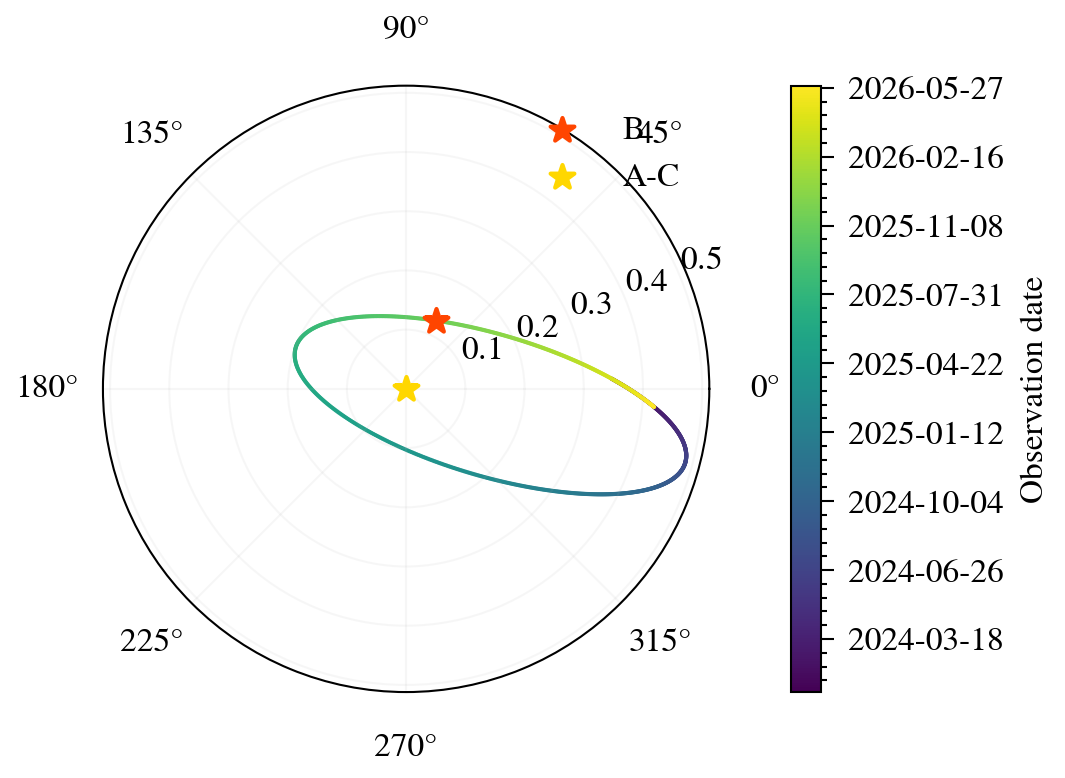

In [139]:
from dLux.utils import deg2rad
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Convert datetimes to numeric values matplotlib can colormap
date_nums = mdates.date2num(dates)

fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})

ax.scatter(deg2rad(theta), rho, marker="*", color="orangered", zorder=3, label="B")
ax.scatter(0, 0, color="gold", marker="*", zorder=2, label="A-C")

# Observed points, colored by date
sc = ax.scatter(
    deg2rad(predictions[1]), predictions[0],
    c=date_nums,
    cmap="viridis",
    marker=".",
    s=1,
    linewidth=0.5,
    zorder=1,
)

# Origin marker (primary star)

ax.grid(True, alpha=0.1)

# Colorbar with date-formatted ticks
cbar = fig.colorbar(sc, ax=ax, pad=0.1)
cbar.ax.yaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
cbar.set_label("Observation date")

plt.legend()
plt.show()

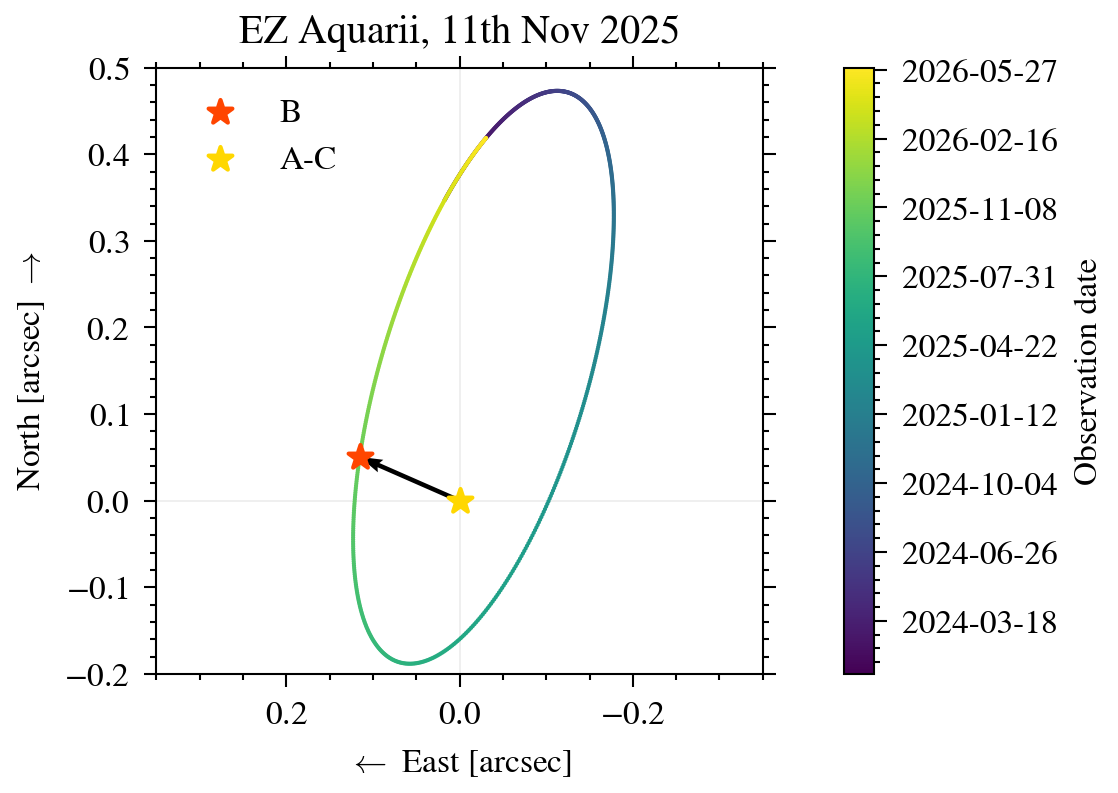

In [172]:
from dLux.utils import deg2rad
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Convert datetimes to numeric values matplotlib can colormap
date_nums = mdates.date2num(dates)

# Convert (rho, theta) -> (x, y); theta is position angle (East of North)
def polar_to_xy(rho, theta_deg):
    theta_rad = deg2rad(theta_deg)
    x = rho * np.sin(theta_rad)   # East
    y = rho * np.cos(theta_rad)   # North
    return x, y

x_obs, y_obs = polar_to_xy(rho, theta)
x_pred, y_pred = polar_to_xy(predictions[0], predictions[1])

fig, ax = plt.subplots()

ax.scatter(x_obs, y_obs, marker="*", color="orangered", zorder=3, label="B")
ax.scatter(0, 0, color="gold", marker="*", zorder=2, label="A-C")
ax.quiver(0, 0, x_obs, y_obs, angles='xy', scale_units='xy', scale=1)

# Orbit prediction, colored by date
sc = ax.scatter(
    x_pred, y_pred,
    c=date_nums,
    cmap="viridis",
    marker=".",
    s=1,
    linewidth=0.5,
    zorder=1,
)


ax.set_xlabel('$\\leftarrow$ East [arcsec]')
ax.set_ylabel('North [arcsec] $\\rightarrow$')
ax.set_aspect("equal")
ax.set(
    xlim=(-0.35, 0.35),
    ylim=(-0.2, 0.5),
    title="EZ Aquarii, 11th Nov 2025",
)
ax.axhline(0, linewidth=0.1, color="k", alpha=0.3, zorder=-1)
ax.axvline(0, linewidth=0.1, color="k", alpha=0.3, zorder=-1)
# ax.grid(True, alpha=0.2)

# Colorbar with date-formatted ticks
cbar = fig.colorbar(sc, ax=ax, pad=0.1)
cbar.ax.yaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
cbar.set_label("Observation date")
ax.invert_xaxis()
ax.legend()
plt.show()

In [171]:
print(f"Separation rho: {rho:.4f} arcsec")
print(f"Position angle: {theta:.2f} deg (East of North)")

Separation rho: 0.1259 arcsec
Position angle: 66.31 deg (East of North)
